# 01 — Exploratory data analysis of the synthetic seed dataset

**Lesson 1 in practice** ([notes](../docs/learning/01-datasets-and-weak-labels.md)).
Before any model sees this data, we look at it. EDA answers three questions:

1. **What will the model learn from?** Class balance, text style, vocabulary.
2. **Where can evaluation lie to us?** Duplicates, family-specific words (names, pets).
3. **How trustworthy are the labels?** Generator quality, ambiguous categories.

Everything here reads the database through `ml/datasets.py`. Set `DATABASE_URL` to the
database you want to analyse (production holds the seed dataset).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "backend"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ml.datasets import dataset_hash, load_generation_runs, load_labelled

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)

# Chart styling: one hue for single-series charts, recessive axes.
BLUE, INK, MUTED, SURFACE = "#2a78d6", "#0b0b0b", "#898781", "#fcfcfb"
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

df = load_labelled()
runs = load_generation_runs()
print(f"{len(df)} labelled topics from {df['household_id'].nunique()} households")
print("sources:", df["source"].value_counts().to_dict())
print("dataset hash:", dataset_hash(df)[:16], "…")

AUTH_SECRET missing or short; using an insecure development secret


2400 labelled topics from 12 households
sources: {'simulated': 2400}
dataset hash: b81598bfbd36f411 …


## 1. Families

Each row is one simulated family. They should all be close to the 200-ticket target.

In [2]:
families = (
    df.groupby(["preset_key", "household_name"])
    .agg(topics=("topic_id", "size"), categories=("category", "nunique"))
    .reset_index()
    .sort_values("preset_key")
)
families

,preset_key,household_name,topics,categories
0,big-family,Familie Jansen (demo),200,7
1,city-apartment,Familie Smit (demo),200,7
2,couple-no-kids,Familie de Vries (demo),200,6
3,single-parent,Familie Bakker (demo),200,7
4,teenagers,Familie de Boer (demo),200,7
5,typical-1,Familie Meijer (demo),200,7
6,typical-2,Familie Bakker (demo),200,7
7,typical-3,Familie Visser (demo),200,7
8,typical-4,Familie Visser (demo),200,7
9,typical-5,Familie Meijer (demo),200,7


## 2. Class balance: categories

**Why it matters:** if one category is 5× more common than another, a lazy model can
score high *accuracy* by favouring the big class and still be useless on the small ones.
That is why Phase 3 reports **macro-F1** (the average over classes, each class counting
equally) instead of accuracy alone.

The imbalance here is *intended*: it comes from the family weights in `sim/family.py`
(pets → more chores, garden → more maintenance, no kids → no `kids`).

,tickets,percent
category,,
chores,580,24.2
groceries,508,21.2
kids,445,18.5
home_maintenance,408,17.0
social,190,7.9
finance,178,7.4
other,91,3.8


imbalance ratio (largest / smallest class): 6.4


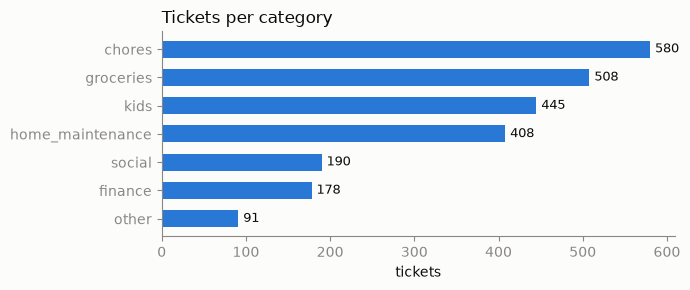

In [3]:
counts = df["category"].value_counts()
share = (counts / counts.sum() * 100).round(1)
display(pd.DataFrame({"tickets": counts, "percent": share}))
print(f"imbalance ratio (largest / smallest class): {counts.max() / counts.min():.1f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(counts.index[::-1], counts.values[::-1], color=BLUE, height=0.6)
for y, v in enumerate(counts.values[::-1]):
    ax.text(v + counts.max() * 0.01, y, f"{v}", va="center", color=INK, fontsize=9)
ax.set_title("Tickets per category", loc="left", color=INK)
ax.set_xlabel("tickets")
plt.tight_layout()
plt.show()

## 3. Category mix per family

**What to look for:** does each family's mix match its situation? A family without kids
must have ~0% `kids`; families with a garden more `home_maintenance`. If Gemini ignored
the requested categories, this table would look uniform.

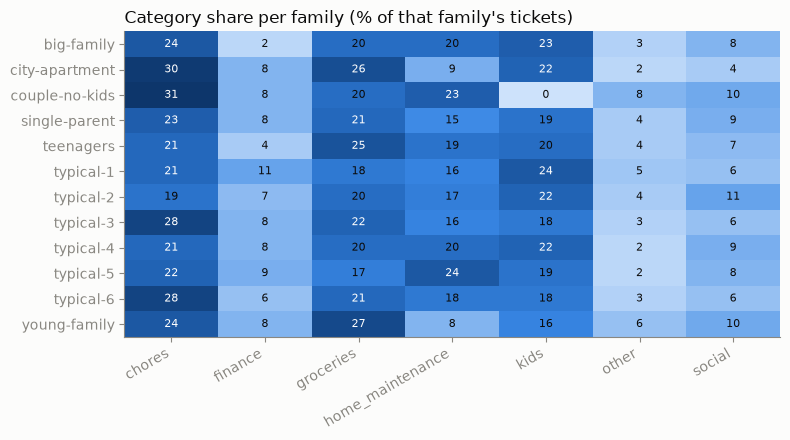

In [4]:
mix = pd.crosstab(df["preset_key"], df["category"], normalize="index").mul(100).round(0)

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(mix.values, cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("b", BLUES), aspect="auto")
ax.set_xticks(range(mix.shape[1]), mix.columns, rotation=30, ha="right")
ax.set_yticks(range(mix.shape[0]), mix.index)
for i in range(mix.shape[0]):
    for j in range(mix.shape[1]):
        v = mix.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > 20 else INK)
ax.set_title("Category share per family (% of that family's tickets)", loc="left", color=INK)
plt.tight_layout()
plt.show()

## 4. Effort labels

**Why it matters:** effort is the second target. In the first 25-ticket sample Gemini
gave 19× S, 6× M, 0× L. If `L` stays rare, the effort model will almost never predict it
(it's cheaper to be wrong on a rare class). We also check whether effort depends on
category, which is what makes it learnable from text at all.

In [5]:
print(df["effort"].value_counts().reindex(["S", "M", "L"]).to_dict())
by_cat = pd.crosstab(df["category"], df["effort"], normalize="index").reindex(columns=["S", "M", "L"]).mul(100).round(0)
by_cat

{'S': 1909, 'M': 458, 'L': 33}


effort,S,M,L
category,,,
chores,76.0,24.0,0.0
finance,80.0,19.0,2.0
groceries,99.0,1.0,0.0
home_maintenance,65.0,29.0,5.0
kids,73.0,27.0,0.0
other,86.0,14.0,0.0
social,82.0,14.0,4.0


## 5. Text style: is it realistic?

Real family members type short, informal notes. We asked Gemini for a style mix
(35% terse, 15% sloppy, ...). Check: length distribution, share of very short tickets,
lowercase-only, and whether kids write differently from adults.

,median words,≤ 3 words %,lowercase only %,contains '!!' %
0,7.0,33.7,49.9,8.8


,count,mean,50%,max
submitter_role,,,,
adult,1986.0,7.6,7.0,23.0
kid,414.0,5.8,4.0,16.0


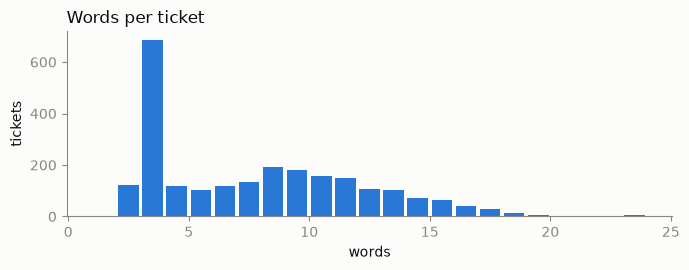

In [6]:
words = df["text"].str.split().str.len()
style = pd.DataFrame({
    "median words": [words.median()],
    "≤ 3 words %": [(words <= 3).mean() * 100],
    "lowercase only %": [(df["text"] == df["text"].str.lower()).mean() * 100],
    "contains '!!' %": [df["text"].str.contains("!!", regex=False).mean() * 100],
}).round(1)
display(style)
display(df.assign(words=words).groupby("submitter_role")["words"].describe()[["count", "mean", "50%", "max"]].round(1))

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist(words, bins=range(1, int(words.max()) + 2), color=BLUE, rwidth=0.85)
ax.set_title("Words per ticket", loc="left", color=INK)
ax.set_xlabel("words")
ax.set_ylabel("tickets")
plt.tight_layout()
plt.show()

## 6. What words carry the signal — and which ones shouldn't

A text classifier learns which words go with which label. We want words like *maaien*,
*boodschappen*, *belasting*. We do **not** want it to rely on **names of people and pets**:
*"Luna"* is the dog in one family and a daughter in another. Those words are
family-specific, which is exactly why the holdout contains *whole unseen families*.

In [7]:
from sim.family import _CAT_NAMES, _DOG_NAMES, _NAMES

names = {n.lower() for pool in _NAMES.values() for n in pool} | {n.lower() for n in _DOG_NAMES + _CAT_NAMES}
tokens = df["text"].str.lower().str.findall(r"[a-zà-ÿ]+")
mentions_name = tokens.map(lambda ts: any(t in names for t in ts))
print(f"tickets mentioning a person or pet name: {mentions_name.mean() * 100:.0f}%")

STOP = set("de het een en van voor op in te met aan naar om is bij nog even ff ik we je mijn onze of al dit die dat er ook wie weer".split())
top = {}
for cat, group in df.groupby("category"):
    counts = pd.Series([t for ts in tokens[group.index] for t in ts if t not in STOP and len(t) > 2]).value_counts()
    top[cat] = ", ".join(counts.head(8).index)
pd.Series(top, name="most frequent words").to_frame()

tickets mentioning a person or pet name: 34%


,most frequent words
chores,"moet, vanavond, worden, moeten, vaatwasser, eten, was, grondig"
finance,"moet, betalen, vergelijken, controleren, autoverzekering, maand, overmaken, ..."
groceries,"halen, mee, meenemen, kopen, vanmiddag, appels, hebben, werk"
home_maintenance,"moet, worden, fiets, dakgoot, auto, gaat, smeren, bladeren"
kids,"moet, school, nieuwe, emma, noah, lieke, kopen, milan"
other,"afspraak, controle, tandarts, moet, paspoort, kapper, maken, halfjaarlijkse"
social,"kopen, cadeautje, verjaardag, sturen, kaartje, opa, tante, oma"


## 7. Duplicates and near-duplicates

LLMs repeat themselves. The generator already drops exact duplicates *within* a family,
but the same ticket can appear in *different* families (*"gras maaien"*). If one copy
lands in training and the other in the holdout, the model is tested on something it
memorised. Two checks:

- **exact** duplicates after normalisation (lowercase, no punctuation);
- **near**-duplicates: character n-gram TF-IDF vectors with cosine similarity ≥ 0.85
  (a preview of Phase 3's text features: similar strings → similar vectors).

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

dup_groups = df.groupby("text_hash").filter(lambda g: len(g) > 1)
print(f"exact duplicates: {len(dup_groups)} tickets in {dup_groups['text_hash'].nunique()} groups "
      f"({dup_groups['text_hash'].nunique() / df['text_hash'].nunique() * 100:.1f}% of unique texts), "
      f"across families: {(dup_groups.groupby('text_hash')['household_id'].nunique() > 1).sum()} groups")
display(dup_groups.groupby("text_hash").agg(text=("text", "first"), copies=("text", "size"), families=("household_id", "nunique"))
        .sort_values("copies", ascending=False).head(8).reset_index(drop=True))

vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2)
X = vec.fit_transform(df["text"].str.lower())
sim = cosine_similarity(X, dense_output=False)
sim.setdiag(0)
sim = sim.multiply(sim >= 0.85).tocoo()
households = df["household_id"].to_numpy()
pairs = [(i, j, v) for i, j, v in zip(sim.row, sim.col, sim.data) if i < j and households[i] != households[j]]
print(f"near-duplicate pairs across families (cosine ≥ 0.85): {len(pairs)}")
pd.DataFrame([(df['text'].iat[i], df['text'].iat[j], round(v, 2)) for i, j, v in sorted(pairs, key=lambda p: -p[2])[:10]],
             columns=["text A", "text B", "cosine"])

exact duplicates: 279 tickets in 109 groups (4.9% of unique texts), across families: 109 groups


,text,copies,families
0,was ophangen zolder,9,9
1,De filters van de afzuigkap moeten in de vaatwasser.,7,7
2,appels voor appeltaart,5,5
3,cadeau opa kopen,5,5
4,hagelslag en pindakaas,5,5
5,vaatwasser leegruimen,5,5
6,appels en peren,5,5
7,energiecontract vergelijken september,4,4


near-duplicate pairs across families (cosine ≥ 0.85): 600


,text A,text B,cosine
0,Paspoort ophalen bij het gemeentehuis.,Paspoort ophalen bij het gemeentehuis.,1.0
1,afwasmiddel en sponsjes,afwasmiddel en sponsjes,1.0
2,konijnenhok schoonmaken,konijnenhok schoonmaken,1.0
3,konijnenhok schoonmaken,konijnenhok schoonmaken,1.0
4,konijnenhok schoonmaken,konijnenhok schoonmaken,1.0
5,keukenkastjes binnenkant schoonmaken,keukenkastjes binnenkant schoonmaken,1.0
6,We moeten nog appels en peren halen voor de fruitschaal.,We moeten nog appels en peren halen voor de fruitschaal.,1.0
7,zorgverzekering declaratie indienen,declaratie zorgverzekering indienen,1.0
8,groene container buitenzetten,groene container buitenzetten,1.0
9,De ramen aan de straatkant lappen,De ramen aan de straatkant lappen,1.0


## 8. Generator quality (lineage)

Per generation run: how much was rejected, how often Gemini labelled a text differently
from the category we requested, which models answered, and what it cost.

In [9]:
display(runs[["preset_key", "status", "requested", "produced", "rejected_invalid", "rejected_duplicate",
              "category_mismatches", "tokens_in", "tokens_out"]])
totals = runs[["produced", "rejected_invalid", "rejected_duplicate", "category_mismatches", "tokens_in", "tokens_out"]].sum()
print(totals.to_dict())
print("models used:", pd.Series([m for d in runs["models_used"] for m, n in d.items() for _ in range(n)]).value_counts().to_dict())

,preset_key,status,requested,produced,rejected_invalid,rejected_duplicate,category_mismatches,tokens_in,tokens_out
0,typical-2,failed,200,25,0,0,0,1754,887
1,typical-3,failed,200,25,0,0,0,1757,934
2,typical-1,failed,200,25,0,0,0,1762,904
3,typical-4,failed,200,0,0,0,0,0,0
4,typical-5,failed,200,0,0,0,0,0,0
5,typical-6,failed,200,0,0,0,0,0,0
6,city-apartment,failed,200,0,0,0,0,0,0
7,single-parent,failed,200,0,0,0,0,0,0
8,couple-no-kids,failed,200,0,0,0,0,0,0
9,big-family,failed,200,0,0,0,0,0,0


{'produced': 2400, 'rejected_invalid': 0, 'rejected_duplicate': 66, 'category_mismatches': 64, 'tokens_in': 244625, 'tokens_out': 101219}
models used: {'gemini-3.5-flash': 114}


## 9. Findings

### Findings (seed dataset v1, 2,400 tickets, 12 families)

**1. Class balance: imbalanced as intended.** `chores` 24%, `groceries` 21%, `kids` 19%,
`home_maintenance` 17%, `social` 8%, `finance` 7%, `other` 4% (ratio 6.4). The per-family
mix follows the world model (no kids → 0% `kids`; apartments ~8% maintenance vs 15–24% for
houses). ⇒ Report **macro-F1 and per-class scores**. `other` has only ~90 examples in total,
so in a 3-family holdout its score rests on ~20 tickets: treat it as noisy.

**2. Effort: severely imbalanced.** S 80%, M 19%, **L 1.4% (33 tickets)**; groceries are 99% S.
A model that always answers "S" scores **80% accuracy while being useless**, the
classic baseline trap we'll demonstrate in Phase 3. `L` is barely learnable from this data.
Part of this is a generator artefact: we asked for many terse tickets, and short texts read as
small tasks. ⇒ Phase 3: compare against a majority baseline, use class weights, treat effort as
ordinal. Real sprint reviews (`effort_actual`) will be the true effort signal.

**3. Style: plausible.** Median 7 words (adults 7, kids 4), a third of tickets ≤ 3 words, half
all-lowercase, typos present. Probably still a bit longer and neater than real input:
the sim-to-real gap we'll measure once real data arrives.

**4. Family-specific words: 34% of tickets mention a person or pet name.** The most frequent
`kids` words include *emma, noah, lieke, milan*. A model can learn "Lieke → kids", which only
works inside that family. ⇒ This is why the holdout contains **whole unseen families**.
Possible Phase 3 experiment: replace names with a placeholder token.

**5. Duplicates across families.** 109 texts appear in several families (279 tickets, 5% of
unique texts; *"was ophangen zolder"* in 9 families), plus ~600 near-duplicate pairs
(*"zorgverzekering declaratie indienen"* vs *"declaratie zorgverzekering indienen"*).
Exact duplicates of holdout texts are already excluded from training by hash. ⇒ Phase 3:
also exclude **near**-duplicates of holdout texts, or the holdout score is optimistic.

**6. Hallucinated pets.** 19 tickets (0.8%) mention rabbits, guinea pigs or birds that no
family has (7 of them in `single-parent`, which has no pets at all). The labels are still
correct (`chores`), so they're harmless for classification, but they break the family's
consistency. ⇒ Prompt v2 (`gen-v2`): say explicitly that the family has no other pets.
Existing tickets keep `gen-v1` in their lineage.

**7. Generator quality.** 0 invalid items, 66 duplicates dropped (2.7%), 64 re-labelled by
Gemini (2.7%), all by `gemini-3.5-flash`, ~345k tokens in total (a few cents). Failed runs
from the quota/crash episodes stay visible in the lineage table: history isn't rewritten.